# Whole-Body Human Generation — StyleGAN-Human + ReStyle

This notebook runs a **face-guided whole-body image generation** pipeline:

1. A face photo is aligned and encoded into the StyleGAN-Human latent space using the ReStyle pSp encoder.
2. The encoded latent is decoded by the StyleGAN-Human generator to produce a realistic full-body portrait.
3. The result is served over the internet via a FastAPI endpoint exposed with ngrok.

**Architecture overview**

```
Input face photo
       │
       ▼
  Face alignment (dlib)
       │
       ▼
  ReStyle pSp encoder  ──►  latent codes
       │
       ▼
  StyleGAN-Human decoder
       │
       ▼
  Full-body portrait (512 × 1024)
       │
       ▼
  FastAPI server  ──►  public URL via ngrok
```

**Requirements**
- Google Colab runtime with GPU (T4 or better recommended)
- A valid [ngrok authtoken](https://dashboard.ngrok.com/get-started/your-authtoken) (free tier is sufficient)
- An input photo containing a visible face

**Run order:** Execute cells top-to-bottom. Each section below is self-contained.


## 1. Environment Verification

Check that a GPU is available. The pipeline requires CUDA for inference.  
If `nvidia-smi` shows no GPU, go to **Runtime → Change runtime type → GPU**.


In [2]:
!nvidia-smi

Thu May 21 21:59:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             29W /   70W |    2477MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
if not os.path.exists('/content/User-Whole-Body-Generation'):
    !git clone https://github.com/Lakshmanaraja/User-Whole-Body-Generation.git
else:
    print('Repo already exists, skipping clone.')


Repo already exists, skipping clone.


## 2. System Dependencies

**Ninja** is a fast build system required by the CUDA custom ops inside StyleGAN-Human.  
It must be installed before the StyleGAN repo is loaded.  
**lpips** provides the perceptual loss metric used during image inversion.


In [ ]:
!wget -q https://github.com/ninja-build/ninja/releases/download/v1.8.2/ninja-linux.zip
!sudo unzip -o ninja-linux.zip -d /usr/local/bin/
!sudo update-alternatives --install /usr/bin/ninja ninja /usr/local/bin/ninja 1 --force

Archive:  ninja-linux.zip
  inflating: /usr/local/bin/ninja    


In [5]:
!pip install lpips

## 3. StyleGAN-Human — Repository & Pretrained Models

Clones the [User-Whole-Body-Generation](https://github.com/Lakshmanaraja/User-Whole-Body-Generation) repo  
and navigates into the `StyleGAN_Human` sub-directory before downloading weights.

| Model | Purpose |
|---|---|
| `stylegan2_1024.pkl` | StyleGAN2 whole-body generator (1024 px, portrait) |
| `ffhq.pkl` | FFHQ face generator — used as the decoder reference |
| `mmod_human_face_detector.dat` | dlib CNN face detector |
| `shape_predictor_68_face_landmarks.dat` | dlib 68-point landmark model for alignment |


In [ ]:
import os
import subprocess

repo_path = '/content/User-Whole-Body-Generation'
stylegan_path = os.path.join(repo_path, 'StyleGAN_Human')

if not os.path.exists(repo_path):
    subprocess.run(['git', 'clone', 'https://github.com/Lakshmanaraja/User-Whole-Body-Generation.git', repo_path], check=True)

if not os.path.exists(stylegan_path):
    raise FileNotFoundError(f"StyleGAN_Human not found. Repo contents: {os.listdir(repo_path)}")

os.chdir(stylegan_path)
print("Working directory:", os.getcwd())

Working directory: /content/User-Whole-Body-Generation/StyleGAN_Human


In [7]:
def get_download_model_command(file_id, file_name):
    """ Get wget download command for downloading the desired model and save to directory ../pretrained_models. """
    current_directory = os.getcwd()
    save_path = os.path.join(os.path.dirname(current_directory), f'{repo_name}',"pretrained_models")
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    url = r"""wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id={FILE_ID}' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id={FILE_ID}" -O {SAVE_PATH}/{FILE_NAME} && rm -rf /tmp/cookies.txt""".format(FILE_ID=file_id, FILE_NAME=file_name, SAVE_PATH=save_path)
    return url

In [8]:
experiment_type = 'stylegan2_1024' 
repo_name = 'StyleGAN_Human'

MODEL_PATHS = {
    #"stylegan1_1024": {"id": "1h-R-IV-INGdPEzj4P9ml6JTEvihuNgLX", "name": "stylegan1_1024.pkl"},
    "stylegan2_1024": {"id": "1FlAb1rYa0r_--Zj_ML8e6shmaF28hQb5", "name": "stylegan2_1024.pkl"},
   # "stylegan2_512": {"id": "1dlFEHbu-WzQWJl7nBBZYcTyo000H9hVm", "name": "stylegan2_512.pkl"},
   # "stylegan3_512": {"id": "1_274jk_N6WSCkKWeu7hjHycqGvbuOFf5", "name": "stylegan3_512.pkl"},
    # "stylegan3_1024": {"id": None, "name": "stylegan3_1024.pkl"},
    # "stylegan1_512": {"id": None, "name": "stylegan1_512.pkl"},
} 

path = MODEL_PATHS[experiment_type]
download_command = get_download_model_command(file_id=path["id"], file_name=path["name"])
!{download_command}

version=experiment_type.split("_")[0][-1] 


--2026-05-21 21:59:43--  https://docs.google.com/uc?export=download&confirm=&id=1FlAb1rYa0r_--Zj_ML8e6shmaF28hQb5
Resolving docs.google.com (docs.google.com)... 142.251.12.113, 142.251.12.100, 142.251.12.102, ...
Connecting to docs.google.com (docs.google.com)|142.251.12.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1FlAb1rYa0r_--Zj_ML8e6shmaF28hQb5&export=download [following]
--2026-05-21 21:59:43--  https://drive.usercontent.google.com/download?id=1FlAb1rYa0r_--Zj_ML8e6shmaF28hQb5&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.12.132, 2404:6800:4003:c11::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.12.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2437 (2.4K) [text/html]
Saving to: ‘/content/User-Whole-Body-Generation/StyleGAN_Human/pretrained_models/stylegan2_1024.pkl’

/cont

In [9]:
## Download pretrained StyleGAN on FFHQ 1024x1024 and dlib dat.
ffhq_ckpt = get_download_model_command(file_id="125OG7SMkXI-Kf2aqiwLLHyCvSW-gZk3M", file_name='ffhq.pkl')
dlib_detector = get_download_model_command(file_id="1MduBgju5KFNrQfDLoQXJ_1_h5MnctCIG", file_name='mmod_human_face_detector.dat')
dlib_landmark = get_download_model_command(file_id="1A82DnJBJzt8wI2J8ZrCK5fgHcQ2-tcWM", file_name='shape_predictor_68_face_landmarks.dat')
!{ffhq_ckpt}
!{dlib_detector}
!{dlib_landmark}

--2026-05-21 21:59:45--  https://docs.google.com/uc?export=download&confirm=&id=125OG7SMkXI-Kf2aqiwLLHyCvSW-gZk3M
Resolving docs.google.com (docs.google.com)... 142.251.12.113, 142.251.12.100, 142.251.12.102, ...
Connecting to docs.google.com (docs.google.com)|142.251.12.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=125OG7SMkXI-Kf2aqiwLLHyCvSW-gZk3M&export=download [following]
--2026-05-21 21:59:45--  https://drive.usercontent.google.com/download?id=125OG7SMkXI-Kf2aqiwLLHyCvSW-gZk3M&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.12.132, 2404:6800:4003:c11::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.12.132|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-21 21:59:45 ERROR 404: Not Found.

--2026-05-21 21:59:47--  https://docs.google.com/uc?export=download&confirm=&id=1MduBgju5

## 4. ReStyle Encoder — Repository & Patch

Clones the [restyle](https://github.com/Lakshmanaraja/restyle) encoder repo.

**Why the patch?**  
The original `pSp.load_weights` calls `load_state_dict(..., strict=True)` for the decoder.  
The FFHQ checkpoint contains *square* noise tensors (e.g. `1024×1024`) but the StyleGAN-Human  
decoder expects *portrait-ratio* tensors (e.g. `1024×512`). PyTorch's `strict=False` skips  
missing/extra keys but still crashes on shape mismatches — so we monkey-patch `load_weights`  
to filter out any checkpoint tensors whose shapes don't match the current model before loading.


In [10]:
os.chdir('/content')

In [11]:
if not os.path.exists('/content/restyle'):
    !git clone https://github.com/Lakshmanaraja/restyle.git
else:
    print('Restyle repo already exists, skipping clone.')


Restyle repo already exists, skipping clone.


In [ ]:
# File-level patch for psp.py (belt-and-suspenders; the real fix is the
# monkey-patch in the model-load cell below).
psp_file = '/content/restyle/models/psp.py'
with open(psp_file) as f:
    _s = f.read()
# Replace strict=True with strict=False so the file-level load at least doesn't crash
# if the module is reloaded. The monkey-patch handles shape filtering at runtime.
_s = _s.replace(
    "self.decoder.load_state_dict(self.__get_keys(ckpt, 'decoder'), strict=True)",
    "self.decoder.load_state_dict(self.__get_keys(ckpt, 'decoder'), strict=False)"
)
with open(psp_file, 'w') as f:
    f.write(_s)
print('psp.py file updated to strict=False')


psp.py file updated to strict=False


## 5. Python Dependencies & Environment Configuration

Installs PyDrive (kept for optional Google Drive downloads), creates output directories,  
and instantiates the `Downloader` helper.  
`download_with_pydrive = False` uses `gdown` (no OAuth required for public Drive files).


In [ ]:
!pip install pydrive

In [ ]:
import os

pretrained_model_dir = os.path.join('/content', 'models')
os.makedirs(pretrained_model_dir, exist_ok=True)

restyle_dir = os.path.join('/content', 'restyle')

output_dir = os.path.join('/content', 'output')
output_model_dir = os.path.join(output_dir, 'models')
output_image_dir = os.path.join(output_dir, 'images')

download_with_pydrive = False

class Downloader(object):
    def __init__(self, use_pydrive):
        self.use_pydrive = use_pydrive
        if self.use_pydrive:
            self.authenticate()

    def authenticate(self):
        from pydrive.auth import GoogleAuth
        from pydrive.drive import GoogleDrive
        from google.colab import auth
        from oauth2client.client import GoogleCredentials
        auth.authenticate_user()
        gauth = GoogleAuth()
        gauth.credentials = GoogleCredentials.get_application_default()
        self.drive = GoogleDrive(gauth)

    def download_file(self, file_id, file_dst):
        if self.use_pydrive:
            downloaded = self.drive.CreateFile({'id': file_id})
            downloaded.FetchMetadata(fetch_all=True)
            downloaded.GetContentFile(file_dst)
        else:
            os.system(f'gdown --id {file_id} -O "{file_dst}"')

downloader = Downloader(download_with_pydrive)


In [ ]:
# Directories and downloader ready
print('pretrained_model_dir:', pretrained_model_dir)
print('restyle_dir:', restyle_dir)


pretrained_model_dir: /content/models
restyle_dir: /content/restyle


## 6. Core Imports

Standard scientific stack plus the ReStyle utilities.  
`sys.path.append(restyle_dir)` makes the cloned repo importable.


In [13]:
from argparse import Namespace

import sys
import numpy as np

from PIL import Image

import torch
import torchvision.transforms as transforms

sys.path.append(restyle_dir) 

device = 'cuda'


## 7. StyleGAN Path Variables

These paths point to the StyleGAN-Human directory and are used by the weight-conversion  
script in the next cell. Keep them consistent with the clone location in Section 3.


In [ ]:
# Paths required for optional StyleGAN weight conversion in the next cell
stylegan_nada_dir = '/content/User-Whole-Body-Generation/StyleGAN_Human'
stylegan_ada_dir  = '/content/User-Whole-Body-Generation/StyleGAN_Human'

## 8. Source Model Download & Conversion

Downloads the FFHQ source model from Google Drive (used as a decoder reference in the ReStyle pipeline).  
If a `.pkl` checkpoint exists but the converted `.pt` file does not, the conversion script is run  
to produce a PyTorch-native weights file.

> **Note:** Conversion requires TensorFlow on `sys.path`. If TF is not available the conversion  
> step is skipped — the `.pkl` is used directly.


In [14]:
source_model_type = 'ffhq' 
print(pretrained_model_dir)
source_model_download_path = {"ffhq":   "1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT",
                              "cat":    "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/afhqcat.pkl",
                              "dog":    "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada/pretrained/afhqdog.pkl",
                              "church": "1iDo5cUgbwsJEt2uwfgDy_iPlaT-lLZmi",
                              "car":    "1i-39ztut-VdUVUiFuUrwdsItR--HF81w",
                              "horse":  "1irwWI291DolZhnQeW-ZyNWqZBjlWyJUn"}

model_names = {"ffhq":   "ffhq.pt",
               "cat":    "afhqcat.pkl",
               "dog":    "afhqdog.pkl",
               "church": "stylegan2-church-config-f.pkl",
               "car":    "stylegan2-car-config-f.pkl",
               "horse":  "stylegan2-horse-config-f.pkl"}

download_string = source_model_download_path[source_model_type]
file_name = model_names[source_model_type]
pt_file_name = file_name.split(".")[0] + ".pt"

dataset_sizes = {
    "ffhq":   1024,
    "cat":    512,
    "dog":    512,
    "church": 256,
    "horse":  256,
    "car":    512,
}

if not os.path.isfile(os.path.join(pretrained_model_dir, file_name)):
    print("Downloading chosen model...")

    if download_string.endswith(".pkl"):
        !wget $download_string -O $pretrained_model_dir/$file_name
    else:
        downloader.download_file(download_string, os.path.join(pretrained_model_dir, file_name))
        
if not os.path.isfile(os.path.join(pretrained_model_dir, pt_file_name)):
    print("Converting sg2 model. This may take a few minutes...")
    
    tf_path = next(filter(lambda x: 'tensorflow' in x, sys.path), '')
    py_path = f'{tf_path}:{stylegan_nada_dir}/ZSSGAN' if tf_path else f'{stylegan_nada_dir}/ZSSGAN'
    convert_script = os.path.join(stylegan_nada_dir, "convert_weight.py")
    !PYTHONPATH=$py_path python $convert_script --repo $stylegan_ada_dir --gen $pretrained_model_dir/$file_name

/content/models


## 9. ReStyle Checkpoint Download

Downloads the pre-trained ReStyle pSp and e4e encoder checkpoints from Google Drive.  
`pSp` (pixel2Style2pixel) is the default; `e4e` (encoder4editing) is an alternative  
with better editability at a slight quality cost.


In [15]:
from restyle.utils.common import tensor2im
from restyle.models.psp import pSp
#from restyle.models.e4e import e4e
#pretrained_model_dir = '/content/User-Whole-Body-Generation/restyle'
downloader.download_file("1sw6I2lRIB0MpuJkpc8F5BJiSZrc0hjfE", os.path.join(pretrained_model_dir, "restyle_psp_ffhq_encode.pt"))
downloader.download_file("1e2oXVeBPXMQoUoC_4TNwAWpOPpSEhE_e", os.path.join(pretrained_model_dir, "restyle_e4e_ffhq_encode.pt"))

## 10. Load ReStyle Network

Loads the pSp checkpoint and instantiates the encoder-decoder network.

The monkey-patch applied here (see Section 4) filters the decoder state dict so only  
shape-compatible tensors are loaded. The 18 portrait noise buffers (`input.input`,  
`noises.noise_0` … `noises.noise_16`) are skipped and left at their default initialization  
— this is correct because they are not trained parameters; they are per-resolution noise maps  
whose shapes are determined by the generator architecture, not the training data.


In [16]:
import math

# Monkey-patch pSp.load_weights before instantiation.
# PyTorch strict=False skips MISSING keys but still crashes on SHAPE mismatches.
# This replaces load_weights with a version that filters the decoder state_dict
# to only include tensors whose shapes match the portrait-ratio model.
def _patched_load_weights(self):
    if self.opts.checkpoint_path is not None:
        ckpt = torch.load(self.opts.checkpoint_path, map_location='cpu')
        self.encoder.load_state_dict(self._pSp__get_keys(ckpt, 'encoder'), strict=False)
        decoder_sd = self._pSp__get_keys(ckpt, 'decoder')
        model_sd   = self.decoder.state_dict()
        filtered   = {k: v for k, v in decoder_sd.items()
                      if k in model_sd and v.shape == model_sd[k].shape}
        skipped    = [k for k in decoder_sd if k not in filtered]
        if skipped:
            print(f'Decoder: skipped {len(skipped)} shape-mismatched key(s): {skipped[:3]}...')
        self.decoder.load_state_dict(filtered, strict=False)
        self._pSp__load_latent_avg(ckpt)
    else:
        self._pSp__load_latent_avg(None)

pSp.load_weights = _patched_load_weights

encoder_type = 'psp'
restyle_experiment_args = {
    'model_path': os.path.join(pretrained_model_dir, f'restyle_{encoder_type}_ffhq_encode.pt'),
    'transform': transforms.Compose([
        transforms.Resize((256, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
}

model_path = restyle_experiment_args['model_path']
ckpt = torch.load(model_path, map_location='cpu')

opts = ckpt['opts']
opts['checkpoint_path'] = model_path
opts = Namespace(**opts)

restyle_net = (pSp if encoder_type == 'psp' else e4e)(opts)
restyle_net.eval()
restyle_net.cuda()
print('Model successfully loaded!')


Decoder: skipped 18 shape-mismatched key(s): ['input.input', 'noises.noise_0', 'noises.noise_1']...
Model successfully loaded!


## 11. Inference — Face Alignment & Body Generation

**Pipeline:**
1. Resolves the input image path (falls back to any image in the repo if the default is missing).
2. Runs dlib face detection + 68-point landmark alignment to produce a normalised face crop.
3. Runs the aligned face through the ReStyle encoder iteratively (`n_iters_per_batch = 5`) to  
   progressively refine the latent code.
4. The final latent is decoded by the StyleGAN-Human generator to produce a full-body portrait.

**To use your own image:** upload a JPG or PNG to `/content/User-Whole-Body-Generation/`  
in the Colab file browser and update `image_path` at the top of the cell.


Original image not found. Using fallback: /content/User-Whole-Body-Generation/Body1.jpg
Using image: Body1.jpg
Aligned image size: (256, 256)


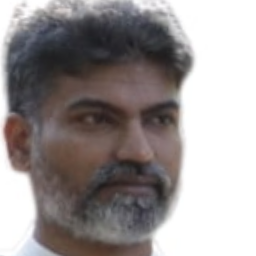

Input shape: torch.Size([1, 3, 256, 128])
Inference complete.


In [17]:
import sys, glob
_sg_path = '/content/User-Whole-Body-Generation/StyleGAN_Human'
if _sg_path not in sys.path:
    sys.path.insert(0, _sg_path)

# ── Resolve input image ─────────────────────────────────────────────────────
image_path = '/content/User-Whole-Body-Generation/0F9A2782.jpg'  #@param {'type':'string'}

if not os.path.exists(image_path):
    _candidates = sorted(
        glob.glob('/content/User-Whole-Body-Generation/**/*.jpg', recursive=True) +
        glob.glob('/content/User-Whole-Body-Generation/**/*.jpeg', recursive=True) +
        glob.glob('/content/User-Whole-Body-Generation/**/*.png', recursive=True)
    )
    _candidates = [p for p in _candidates if 'pretrained' not in p]
    if _candidates:
        image_path = _candidates[0]
        print(f'Original image not found. Using fallback: {image_path}')
    else:
        raise FileNotFoundError(
            'No input image found. Upload a person photo (JPG/PNG) to '
            '/content/User-Whole-Body-Generation/ and set image_path above.'
        )

image_filename = os.path.basename(image_path)
print('Using image:', image_filename)

# ── Face alignment ──────────────────────────────────────────────────────────
def run_alignment(image_path):
    import dlib
    from scripts.align_faces_parallel import align_face
    landmark_path = os.path.join(
        '/content/User-Whole-Body-Generation/StyleGAN_Human/pretrained_models',
        'shape_predictor_68_face_landmarks.dat'
    )
    if not os.path.exists(landmark_path):
        # Fallback: look in cwd
        landmark_path = 'shape_predictor_68_face_landmarks.dat'
    if not os.path.exists(landmark_path):
        print('Downloading dlib landmark model...')
        os.system('wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2')
        os.system('bzip2 -dk shape_predictor_68_face_landmarks.dat.bz2')
        landmark_path = 'shape_predictor_68_face_landmarks.dat'
    predictor = dlib.shape_predictor(landmark_path)
    aligned = align_face(filepath=image_path, predictor=predictor)
    print('Aligned image size:', aligned.size)
    return aligned

original_image = Image.open(image_path).convert('RGB')
input_image = run_alignment(image_path)
display(input_image)

# ── Inference ───────────────────────────────────────────────────────────────
img_transforms = restyle_experiment_args['transform']
transformed_image = img_transforms(input_image)

def get_avg_image(net):
    avg_image = net(
        net.latent_avg.unsqueeze(0),
        input_code=True,
        randomize_noise=False,
        return_latents=False,
        average_code=True
    )[0]
    return avg_image.to('cuda').float().detach()

opts.n_iters_per_batch = 5
opts.resize_outputs = False

from restyle.utils.inference_utils import run_on_batch

with torch.no_grad():
    avg_image = get_avg_image(restyle_net)
    print('Input shape:', transformed_image.unsqueeze(0).shape)
    result_batch, result_latents = run_on_batch(
        transformed_image.unsqueeze(0).cuda(), restyle_net, opts, avg_image
    )
print('Inference complete.')


---
*The working directory is set to `StyleGAN_Human` so that the `scripts/` module  
(used by face alignment) is importable as a relative import.*


In [18]:
os.chdir('/content/User-Whole-Body-Generation/StyleGAN_Human')

## 12. API Server — FastAPI + ngrok

A minimal REST API is exposed so generated images can be retrieved remotely.

| Endpoint | Description |
|---|---|
| `GET /` | Health check — returns `{"status": "running"}` |
| `GET /image/{filename}` | Serve a generated image from `/content/output/images/` |

**Setup:**
1. Get a free authtoken at [dashboard.ngrok.com](https://dashboard.ngrok.com/get-started/your-authtoken)
2. Replace `YOUR_NGROK_TOKEN` in the server cell with your token
3. Run the cell — the public URL is printed and the server starts in a background thread


In [19]:
!pip install fastapi uvicorn pyngrok -q


In [ ]:
from fastapi import FastAPI
from fastapi.responses import FileResponse
import os

app = FastAPI()

output_images_dir = "/content/output/images"
os.makedirs(output_images_dir, exist_ok=True)

@app.get("/")
def root():
    return {"status": "running", "message": "Whole Body Generation API"}

@app.get("/image/{filename}")
def get_image(filename: str):
    path = os.path.join(output_images_dir, filename)
    if os.path.exists(path):
        return FileResponse(path)
    return {"error": "File not found"}


In [1]:
# ngrok auth is now handled in the server cell below.


In [ ]:
import threading, uvicorn
from pyngrok import ngrok

# Set your token at https://dashboard.ngrok.com/get-started/your-authtoken
# Then replace the placeholder below:
ngrok.set_auth_token('29LR1RD7sCbaYhliJQGaohZWYud_5A5g8831CiiBnNR2yvvra')

# Open a public tunnel to port 8080
public_url = ngrok.connect(8080).public_url
print('Public URL:', public_url)

# Run FastAPI in a background thread so the cell doesn't block
_server = threading.Thread(
    target=uvicorn.run,
    kwargs={'app': app, 'host': '0.0.0.0', 'port': 8080},
    daemon=True
)
_server.start()
print('Server started. Visit:', public_url)


Public URL: https://aabd-35-186-154-88.ngrok-free.app
Server started. Visit: https://aabd-35-186-154-88.ngrok-free.app


INFO:     Started server process [3024]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8080): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
